# 1.2 — Kide-inferentzia: señal y límites de la defensa
Original: [1.2_kide_inferentzia_soluzioa.ipynb](../../materialak/1.2_kide_inferentzia_soluzioa.ipynb).
Datos sintéticos: 2.000 muestras, 10 variables, 6 informativas y 2 redundantes; split 50/50, semilla 42. Random Forest de 200 árboles profundos. Conservamos los parámetros del enunciado. La defensa agrupa confianza en 0.5/0.7/0.9; no se presupone que elimine el ataque.


{'train_accuracy': 1.0, 'test_accuracy': 0.915, 'gap': 0.08499999999999996, 'member_confidence': np.float64(0.9420850000000001), 'nonmember_confidence': np.float64(0.868735)}


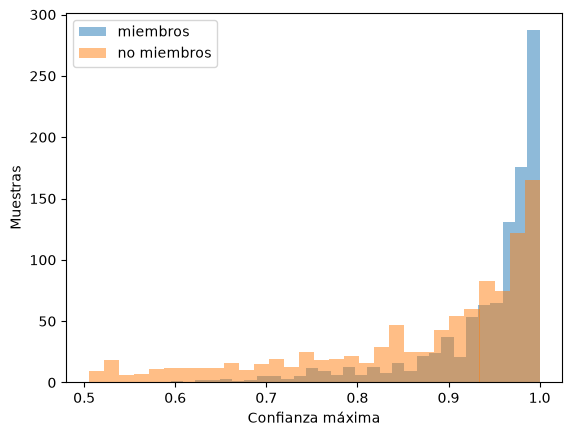

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X, y = make_classification(
    n_samples=2000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=2,
    random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)
model = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=1, random_state=42
)
model.fit(X_train, y_train)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
member = model.predict_proba(X_train).max(axis=1)
nonmember = model.predict_proba(X_test).max(axis=1)
print(
    {
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "gap": train_accuracy - test_accuracy,
        "member_confidence": member.mean(),
        "nonmember_confidence": nonmember.mean(),
    }
)
plt.hist(member, bins=30, alpha=0.5, label="miembros")
plt.hist(nonmember, bins=30, alpha=0.5, label="no miembros")
plt.xlabel("Confianza máxima")
plt.ylabel("Muestras")
plt.legend()
plt.show()

## Ataque y comparación
Accuracy mide la fracción de decisiones correctas de pertenencia, con iguales números de miembros/no miembros. La referencia aleatoria es 0.5. Maximizar el umbral sobre los mismos ejemplos es un resultado exploratorio optimista; por eso añadimos una evaluación independiente del umbral, calibrado en la mitad de cada grupo. No es un ataque con shadow models ni una prueba de extracción de atributos.


{'exploratory_plain': 0.641, 'exploratory_blurred': 0.616, 'reduction': 0.025000000000000022, 'residual_advantage': 0.11599999999999999}


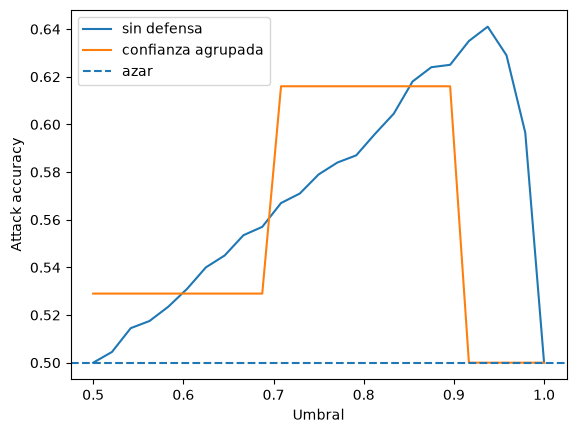

plain {'calibrated_threshold': 0.9375, 'evaluation_accuracy': 0.645}
blurred {'calibrated_threshold': 0.7083333333333333, 'evaluation_accuracy': 0.631}


In [2]:
thresholds = np.linspace(0.5, 1.0, 25)


def attack_accuracy(members, outsiders, threshold):
    return float(
        ((members > threshold).sum() + (outsiders <= threshold).sum())
        / (len(members) + len(outsiders))
    )


def blur(scores):
    return np.where(scores < 0.6, 0.5, np.where(scores < 0.85, 0.7, 0.9))


plain = np.array([attack_accuracy(member, nonmember, t) for t in thresholds])
defended = np.array(
    [attack_accuracy(blur(member), blur(nonmember), t) for t in thresholds]
)
print(
    {
        "exploratory_plain": float(plain.max()),
        "exploratory_blurred": float(defended.max()),
        "reduction": float(plain.max() - defended.max()),
        "residual_advantage": float(defended.max() - 0.5),
    }
)
plt.plot(thresholds, plain, label="sin defensa")
plt.plot(thresholds, defended, label="confianza agrupada")
plt.axhline(0.5, linestyle="--", label="azar")
plt.xlabel("Umbral")
plt.ylabel("Attack accuracy")
plt.legend()
plt.show()
# Las particiones de calibración/evaluación son disjuntas dentro de cada grupo.
rng = np.random.default_rng(43)
mi = rng.permutation(len(member))
ni = rng.permutation(len(nonmember))
for name, transform in [("plain", lambda x: x), ("blurred", blur)]:
    mc, me = transform(member[mi[:500]]), transform(member[mi[500:]])
    nc, ne = transform(nonmember[ni[:500]]), transform(nonmember[ni[500:]])
    t = thresholds[np.argmax([attack_accuracy(mc, nc, x) for x in thresholds])]
    print(
        name,
        {
            "calibrated_threshold": float(t),
            "evaluation_accuracy": attack_accuracy(me, ne, t),
        },
    )
assert member.shape == nonmember.shape == (1000,)
assert np.all((plain >= 0) & (plain <= 1))
assert np.allclose(blur(np.array([0.59, 0.6, 0.84, 0.85])), [0.5, 0.7, 0.7, 0.9])

## Perturbación Laplace ilustrativa
Se compara ε=0.1, 0.5, 1 y 5, con escala 1/ε y clipping [0,1]. Esta celda es una simulación de ruido sobre puntuaciones; no acredita privacidad diferencial del modelo completo. Haría falta definir datos vecinos, sensibilidad global del mecanismo, composición y presupuesto de consultas. Consultar repetidamente y promediar puede reducir el ruido. Una ε pequeña no demuestra anonimato ni desactiva todos los ataques.


In [3]:
for epsilon in [0.1, 0.5, 1.0, 5.0]:
    rng = np.random.default_rng(42)
    noisy_member = np.clip(member + rng.laplace(0, 1 / epsilon, member.shape), 0, 1)
    noisy_nonmember = np.clip(
        nonmember + rng.laplace(0, 1 / epsilon, nonmember.shape), 0, 1
    )
    score = max(attack_accuracy(noisy_member, noisy_nonmember, t) for t in thresholds)
    print({"epsilon_simulation": epsilon, "exploratory_attack_accuracy": score})

{'epsilon_simulation': 0.1, 'exploratory_attack_accuracy': 0.501}
{'epsilon_simulation': 0.5, 'exploratory_attack_accuracy': 0.5065}
{'epsilon_simulation': 1.0, 'exploratory_attack_accuracy': 0.5135}
{'epsilon_simulation': 5.0, 'exploratory_attack_accuracy': 0.557}


## Interpretación, derechos y medidas
El gap train/test y la confianza diferente son señales de generalización imperfecta; no prueban que cada registro se memorice. La defensa se interpreta por la reducción impresa y la ventaja residual sobre 0.5: si persiste una ventaja, la defensa es parcial. En el original guardado 0.641→0.616 significa 2.5 puntos de reducción y 11.6 puntos sobre azar, no anonimato.
Un atacante puede inferir pertenencia a una muestra con error. Que eso revele empleo, enfermedad o afiliación depende del contenido y de cómo se seleccionó el dataset; no permite reconstruir automáticamente todos los atributos de una persona.
RGPD 5: minimizar/limitar finalidad; 9: condiciones adicionales si se revelan categorías especiales; 22: evaluar decisiones exclusivamente automatizadas con efectos jurídicos o similares, no cualquier score; 25 y 32: controles de diseño y seguridad; 35: valorar EIPD según riesgo. El uso para selección/evaluación laboral puede encajar en anexo III.4 del Reglamento IA, sujeto al art. 6 y contexto.
Tres medidas: limitar detalles devueltos y consultas, reducir sobreajuste y evaluar fugas en holdout, y considerar entrenamiento DP con accountant y presupuesto documentado. Añadir minimización, separación de identificadores y supervisión humana. Ninguna medida aislada garantiza ausencia de identificación. No se han procesado datos de empleados reales.


## Fuentes y alcance
Referencias primarias: [RGPD](https://eur-lex.europa.eu/eli/reg/2016/679/oj), [Reglamento de IA](https://eur-lex.europa.eu/eli/reg/2024/1689/oj), [LOPDGDD](https://www.boe.es/buscar/act.php?id=BOE-A-2018-16673), [EDPB: seudonimización](https://www.edpb.europa.eu/topics/ai-and-technology/anonymisation-pseudonymisation_en).
Lectura docente contrastada el 7 de octubre de 2026. La clasificación depende de finalidad, funciones y contexto; citar artículos no certifica cumplimiento. Una EIA ética complementa, pero no sustituye, una EIPD del RGPD ni una evaluación de conformidad. No se han auditado empresas, personas o sistemas reales.
